# Used Car Sale Price Prediction Model (Feedforward Artificial Neural Networks)
#### December 2025
#### By: Bryce Gelarden

### Import 

In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
%matplotlib inline

import seaborn as sns
sns.set(style="darkgrid")

import tensorflow as tf

### Load & Preview

In [ ]:
data_path = r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\Used_Car_Price_Forecasting_NN\train-data.csv"

car_dataset = pd.read_csv(data_path, engine='python')

car_dataset.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


### Audit & Rid Missing Data

In [59]:
car_dataset.isnull().mean()

Unnamed: 0           0.000000
Name                 0.000000
Location             0.000000
Year                 0.000000
Kilometers_Driven    0.000000
Fuel_Type            0.000000
Transmission         0.000000
Owner_Type           0.000000
Mileage              0.000332
Engine               0.005981
Power                0.005981
Seats                0.006978
New_Price            0.863100
Price                0.000000
dtype: float64

In [60]:
car_dataset = car_dataset.drop(['Unnamed: 0', 'New_Price'], axis = 1)

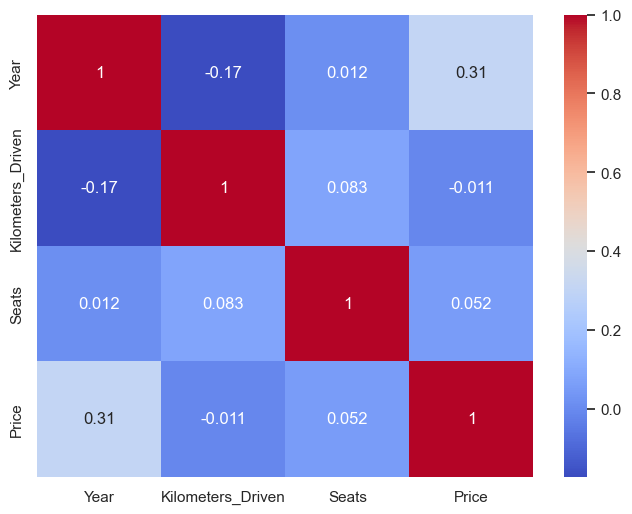

In [61]:
plt.rcParams["figure.figsize"] = [8, 6]

numeric_df = car_dataset.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

C:\Users\Bryce Gelarden\AppData\Local\Temp\ipykernel_27248\966728332.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(car_dataset['Price'])


<Axes: xlabel='Price', ylabel='Density'>

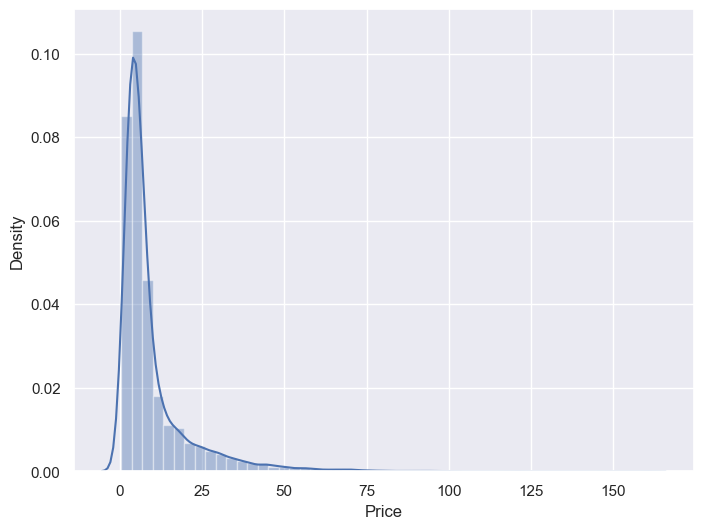

In [62]:
sns.distplot(car_dataset['Price'])

In [63]:
car_dataset.nunique()

Name                 1876
Location               11
Year                   22
Kilometers_Driven    3093
Fuel_Type               5
Transmission            2
Owner_Type              4
Mileage               442
Engine                146
Power                 372
Seats                   9
Price                1373
dtype: int64

In [64]:
print(car_dataset.dtypes)

Name                     str
Location                 str
Year                   int64
Kilometers_Driven      int64
Fuel_Type                str
Transmission             str
Owner_Type               str
Mileage                  str
Engine                   str
Power                    str
Seats                float64
Price                float64
dtype: object


### Feature Engineering & Preprocessing

In [65]:
numerical_data = car_dataset.drop(['Name', 'Location','Fuel_Type', 'Transmission', 'Owner_Type','Mileage','Engine', 'Power'], axis=1) 

numerical_data.head()

,Year,Kilometers_Driven,Seats,Price
0,2010,72000,5.0,1.75
1,2015,41000,5.0,12.50
2,2011,46000,5.0,4.50
3,2012,87000,7.0,6.00
4,2013,40670,5.0,17.74


In [66]:
categorical_data = car_dataset.filter(['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage','Engine','Power'], axis=1)

categorical_data.head()

,Location,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power
0,Mumbai,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp
1,Pune,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp
2,Chennai,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp
3,Chennai,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp
4,Coimbatore,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp


In [67]:
categorical_data__one_hot = pd.get_dummies(categorical_data, drop_first= True) 

categorical_data__one_hot.head()

,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,Location_Hyderabad,Location_Jaipur,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune,...,Power_97.6 bhp,Power_97.7 bhp,Power_98.59 bhp,Power_98.6 bhp,Power_98.79 bhp,Power_98.82 bhp,Power_98.96 bhp,Power_99 bhp,Power_99.6 bhp,Power_null bhp
0,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [68]:
complete_dataset = pd.concat([numerical_data, categorical_data__one_hot ], axis=1)

complete_dataset.head()

,Year,Kilometers_Driven,Seats,Price,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,Location_Hyderabad,Location_Jaipur,...,Power_97.6 bhp,Power_97.7 bhp,Power_98.59 bhp,Power_98.6 bhp,Power_98.79 bhp,Power_98.82 bhp,Power_98.96 bhp,Power_99 bhp,Power_99.6 bhp,Power_null bhp
0,2010,72000,5.0,1.75,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2015,41000,5.0,12.50,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2011,46000,5.0,4.50,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2012,87000,7.0,6.00,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2013,40670,5.0,17.74,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [69]:
complete_dataset.isnull().mean()

Year                  0.000000
Kilometers_Driven     0.000000
Seats                 0.006978
Price                 0.000000
Location_Bangalore    0.000000
                        ...   
Power_98.82 bhp       0.000000
Power_98.96 bhp       0.000000
Power_99 bhp          0.000000
Power_99.6 bhp        0.000000
Power_null bhp        0.000000
Length: 979, dtype: float64

In [70]:
complete_dataset.dropna(inplace = True)

In [71]:
X = complete_dataset.drop(['Price'], axis=1)
y = complete_dataset['Price']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=20)

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

### Model Architecture & Compilation

In [74]:
from tensorflow.keras.layers import Input, Dense, Activation, Dropout

from tensorflow.keras.models import Model

In [75]:
input_layer = Input(shape=(X.shape[1],))
dense_layer0 = Dense(100, activation='relu')(input_layer)
dense_layer1 = Dense(50, activation='relu')(dense_layer0)
dense_layer2 = Dense(25, activation='relu')(dense_layer1)
dense_layer3 = Dense(10, activation='relu')(dense_layer2)
dense_layer4 = Dense(5, activation='relu')(dense_layer3)
dense_layer5 = Dense(2, activation='relu')(dense_layer4)
output = Dense(1)(dense_layer5) 

In [76]:
model = Model(inputs = input_layer, outputs=output)
model.compile(loss="mean_absolute_error", optimizer="adam", metrics=["mean_absolute_error"]) 


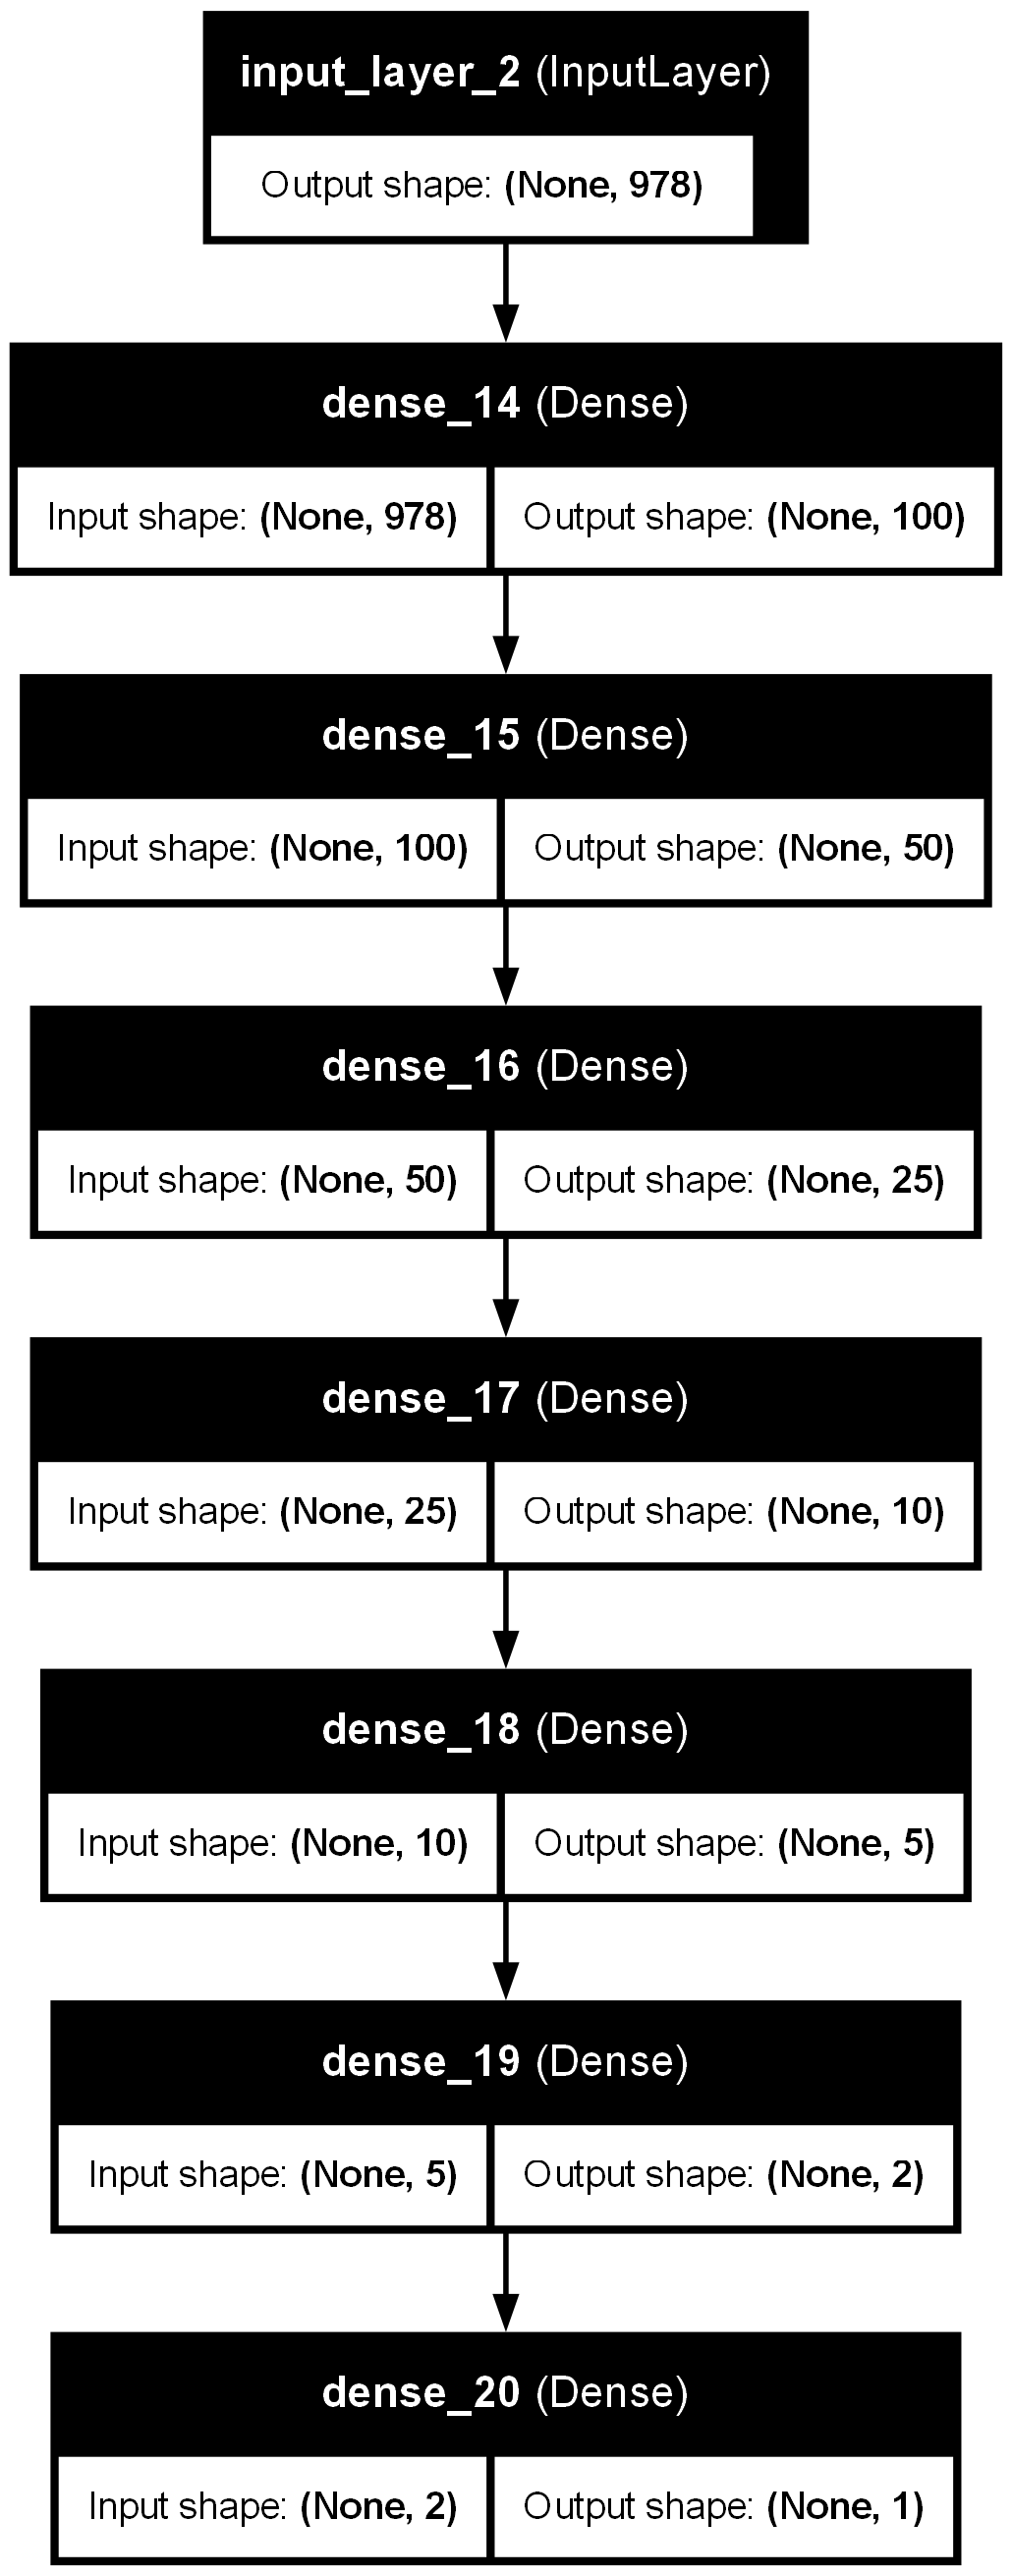

In [77]:
from keras.utils import plot_model

plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True) 

In [78]:
history = model.fit(X_train, y_train, batch_size=5, epochs=5, verbose=1, validation_split=0.2) 

Epoch 1/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3.7058 - mean_absolute_error: 3.7058 - val_loss: 2.3034 - val_mean_absolute_error: 2.3034
Epoch 2/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.1566 - mean_absolute_error: 2.1566 - val_loss: 2.0548 - val_mean_absolute_error: 2.0548
Epoch 3/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.7729 - mean_absolute_error: 1.7729 - val_loss: 1.9634 - val_mean_absolute_error: 1.9634
Epoch 4/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.6036 - mean_absolute_error: 1.6036 - val_loss: 2.0077 - val_mean_absolute_error: 2.0077
Epoch 5/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.5216 - mean_absolute_error: 1.5216 - val_loss: 1.8519 - val_mean_absolute_error: 1.8519


### Training

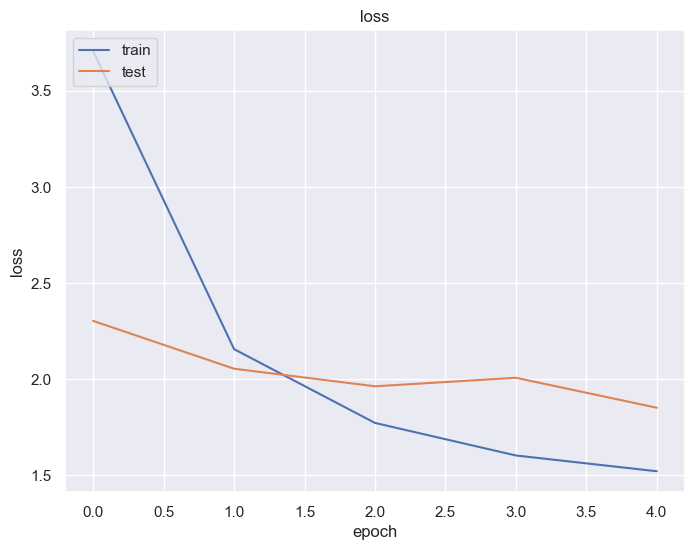

In [79]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show() 

In [80]:
y_pred = model.predict(X_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


### Evaluation & Results

In [81]:
from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))

print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))

print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 1.8337928853744647
Mean Squared Error: 21.361399005350542
Root Mean Squared Error: 4.6218393530444715


In [82]:
car_dataset['Price'].mean()

np.float64(9.47946835022429)

In [83]:
comparison_df = pd.DataFrame({'Actual': y_test.values.tolist(), 'Predicted': y_pred.tolist()})

comparison_df 

,Actual,Predicted
0,8.25,[7.690873622894287]
1,5.08,[4.437170028686523]
2,4.50,[6.3706374168396]
3,28.50,[17.33601188659668]
4,7.25,[10.439645767211914]
...,...,...
1191,7.50,[5.23049783706665]
1192,21.67,[20.28693199157715]
1193,4.60,[5.025176525115967]
1194,8.00,[14.569637298583984]


In [84]:
X_test[1].shape

(978,)

In [85]:
single_point = X_test[1].reshape(1,-1)

single_point.shape

(1, 978)

In [86]:
model.predict(X_test[1].reshape(1,-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


array([[4.4371696]], dtype=float32)

In [87]:
y_test.values[1]

np.float64(5.08)